# 🩺 **Diabetes Risk Prediction**

Dự án xây dựng mô hình Machine Learning dự đoán nguy cơ mắc bệnh tiểu đường dựa trên các chỉ số sức khỏe và lối sống.

**Mục tiêu:**
- Khám phá dữ liệu
- Xây dựng mô hình dự đoán
- So sánh các mô hình
- Đánh giá mô hình tốt nhất

In [59]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

RANDOM_STATE = 42

In [87]:
# Visualization Settings

import matplotlib.pyplot as plt
import seaborn as sns

# Theme
sns.set_theme(style="whitegrid", context="notebook")

# Figure
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120

# Font
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.size"] = 11

# Title
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.titleweight"] = "bold"

# Axis labels
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.labelweight"] = "bold"

# Tick labels
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Legend
plt.rcParams["legend.fontsize"] = 10

# Remove top & right border
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PALETTE = [
    "#BFDBFE",  # Light Blue
    "#60A5FA",  # Blue
    "#2563EB",  # Strong Blue
    "#4F46E5",  # Indigo
    "#7C3AED"   # Violet
]

## **1. Dataset Overview**

### **1.1 Load Dataset**

In [61]:
import pandas as pd

df = pd.read_csv("data/raw/diabetes.csv")
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### **1.2 Dataset Information**

In [62]:
print(f"Shape: {df.shape}")

df.info()

df.describe().T

Shape: (253680, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


### **1.3. Nhóm biến trong bộ dữ liệu**

| Nhóm biến               | Biến                                                                      | Mô tả                                                                   |
| ----------------------- | ------------------------------------------------------------------------- | ----------------------------------------------------------------------- |
| **Biến mục tiêu**       | `Diabetes_012`                                                            | Tình trạng tiểu đường (0: Không mắc, 1: Tiền tiểu đường, 2: Tiểu đường) |
| **Bệnh nền**            | `HighBP`, `HighChol`, `CholCheck`, `Stroke`, `HeartDiseaseorAttack`       | Các chỉ số liên quan đến bệnh tim mạch và cholesterol                   |
| **Lối sống**            | `BMI`, `Smoker`, `PhysActivity`, `Fruits`, `Veggies`, `HvyAlcoholConsump` | Thói quen sinh hoạt và chỉ số cơ thể                                    |
| **Tiếp cận y tế**       | `AnyHealthcare`, `NoDocbcCost`                                            | Khả năng tiếp cận và sử dụng dịch vụ y tế                               |
| **Tình trạng sức khỏe** | `GenHlth`, `MentHlth`, `PhysHlth`, `DiffWalk`                             | Đánh giá sức khỏe tổng quát, thể chất và tinh thần                      |
| **Nhân khẩu học**       | `Sex`, `Age`, `Education`, `Income`                                       | Đặc điểm cá nhân và kinh tế - xã hội                                    |


### **1.4. Nhận xét**

- Bộ dữ liệu gồm **253.680 quan sát** và **22 biến**, đủ lớn để xây dựng và đánh giá mô hình Machine Learning.
- Tất cả các biến đều có **253.680 giá trị hợp lệ (Non-Null)**, cho thấy dữ liệu **không có giá trị thiếu**.
- Các biến đều có kiểu dữ liệu `float64`. Hầu hết là các biến nhị phân hoặc biến rời rạc đã được mã hóa số, thuận lợi cho việc tiền xử lý và xây dựng mô hình.
- Chỉ số **BMI** dao động từ **12 đến 98**, cho thấy tồn tại một số giá trị rất lớn cần được kiểm tra thêm ở bước phân tích ngoại lệ.
- Biến mục tiêu **Diabetes_012** gồm **3 lớp (0, 1, 2)**, phù hợp với bài toán phân loại đa lớp trước khi chuyển đổi sang phân loại nhị phân.
- Nhiều biến như **HighBP, HighChol, Smoker, PhysActivity** là biến nhị phân (0/1), trong khi **BMI, MentHlth, PhysHlth** có nhiều mức giá trị hơn và có thể mang nhiều thông tin dự báo.

## **2. Data Cleaning**

### **2.1 Kiểm tra giá trị thiếu**

In [63]:
# Missing values
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

**Nhận xét**

Bộ dữ liệu không có giá trị thiếu, do đó không cần thực hiện xử lý thiếu dữ liệu trước khi xây dựng mô hình.

### **2.2 Kiểm tra dữ liệu trùng lặp**

In [64]:
# Duplicate records
print(f"Number of duplicated rows: {df.duplicated().sum()}")

Number of duplicated rows: 23899


In [65]:
df = df.drop_duplicates()

print(df.shape)

(229781, 22)


 **Nhận xét**

- Bộ dữ liệu có **23.899 bản ghi trùng lặp**, chiếm khoảng **9,4%** tổng số quan sát.
- Các bản ghi trùng lặp đã được loại bỏ nhằm giảm nhiễu và tránh ảnh hưởng đến quá trình huấn luyện mô hình.
- Sau khi làm sạch, bộ dữ liệu còn **229.781 quan sát** và sẽ được sử dụng cho các bước phân tích tiếp theo.

### **2.3 Kiểm tra kiểu dữ liệu**

In [66]:
df.dtypes.value_counts()

float64    22
Name: count, dtype: int64

**Nhận xét**

- Tất cả **22 biến** trong bộ dữ liệu đều có kiểu dữ liệu `float64`.
- Phần lớn các biến là **biến nhị phân hoặc biến phân loại đã được mã hóa bằng số**, trong khi một số biến như `BMI`, `MentHlth` và `PhysHlth` là biến số liên tục hoặc có nhiều mức giá trị.
- Kiểu dữ liệu hiện tại phù hợp cho quá trình phân tích và xây dựng mô hình Machine Learning, chưa cần chuyển đổi kiểu dữ liệu.

## **3. Exploratory Data Analysis (EDA)**

### **3.1 Phân bố biến mục tiêu**

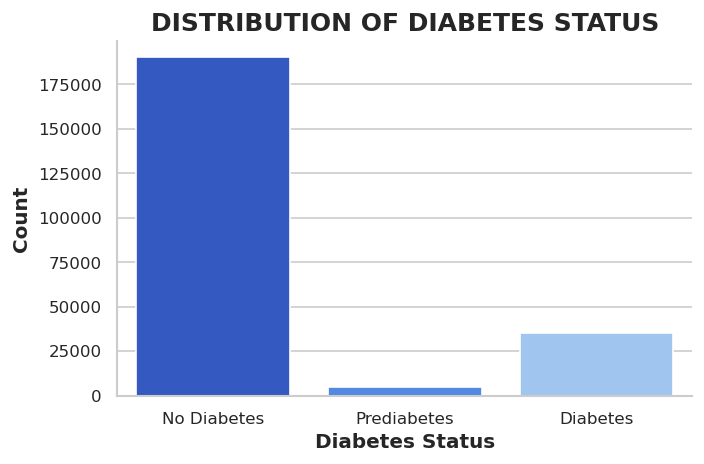

In [67]:
colors = ["#1D4ED8", "#3B82F6", "#93C5FD"]

plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Diabetes_012",
    hue="Diabetes_012",
    palette=colors,
    legend=False
)

plt.title("DISTRIBUTION OF DIABETES STATUS")
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.xticks(
    ticks=[0, 1, 2],
    labels=["No Diabetes", "Prediabetes", "Diabetes"]
)

plt.tight_layout()
plt.show()

**Nhận xét**

- Dữ liệu gồm ba nhóm: **No Diabetes**, **Prediabetes** và **Diabetes**.
- Nhóm **No Diabetes** chiếm đa số, trong khi **Prediabetes** có số lượng mẫu ít nhất, cho thấy bộ dữ liệu bị **mất cân bằng lớp**.
- Ở các bước tiếp theo, **Prediabetes** và **Diabetes** sẽ được gộp thành một lớp để xây dựng bài toán phân loại nhị phân và áp dụng các kỹ thuật xử lý mất cân bằng dữ liệu.

### **3.2 BMI Distribution**

BMI (Body Mass Index) là một trong những chỉ số quan trọng phản ánh tình trạng thể chất và được xem là yếu tố nguy cơ của bệnh tiểu đường. Phần này nhằm quan sát phân bố của chỉ số BMI trong bộ dữ liệu.

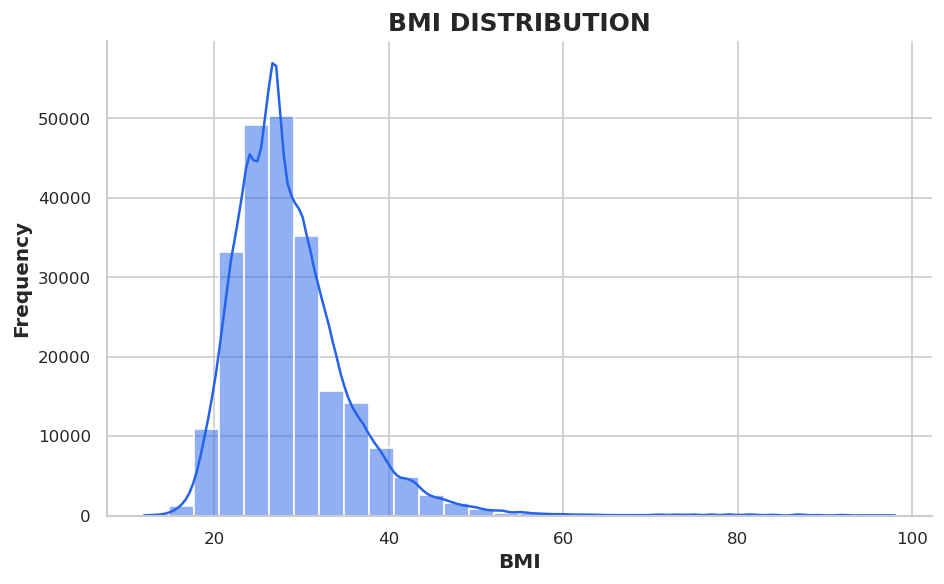

In [68]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="BMI",
    bins=30,
    kde=True,
    color="#2563EB",
    alpha=0.5
)

plt.title("BMI DISTRIBUTION")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Nhận xét**

- Chỉ số BMI có phân bố **lệch phải (right-skewed)**, với phần lớn quan sát tập trung trong khoảng **20–35**.
- Đỉnh phân bố nằm khoảng **25–30**, cho thấy đây là khoảng BMI phổ biến nhất trong bộ dữ liệu.
- Xuất hiện một số giá trị BMI rất cao (lớn hơn 50), cho thấy có thể tồn tại các giá trị ngoại lệ cần được xem xét ở bước tiền xử lý.
- BMI là một trong những yếu tố nguy cơ quan trọng của bệnh tiểu đường, do đó sẽ tiếp tục được phân tích trong các bước tiếp theo.

### **3.3 BMI by Diabetes Status**

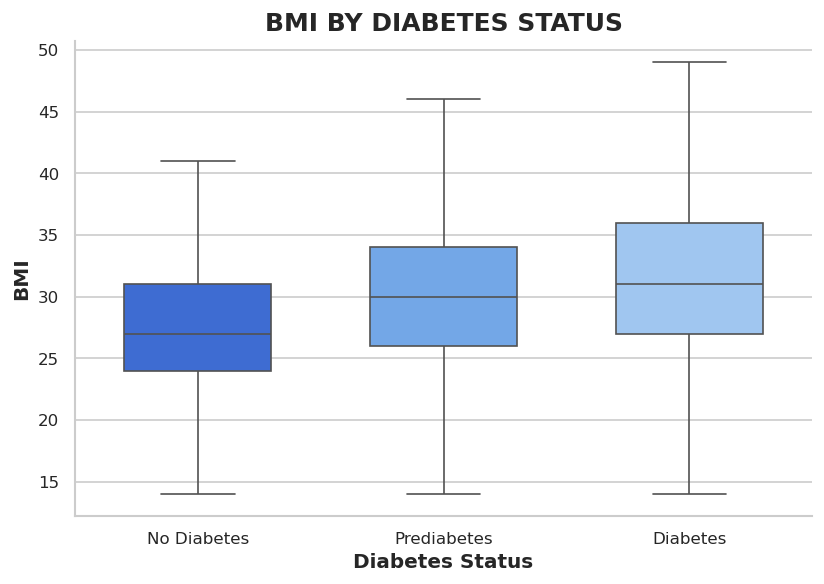

In [69]:
df_plot = df.copy()

df_plot["Diabetes Status"] = df_plot["Diabetes_012"].map({
    0: "No Diabetes",
    1: "Prediabetes",
    2: "Diabetes"
})

# Order of categories
order = ["No Diabetes", "Prediabetes", "Diabetes"]

# Plot
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df_plot,
    x="Diabetes Status",
    y="BMI",
    order=order,
    palette=["#2563EB", "#60A5FA", "#93C5FD"],
    width=0.6,
    showfliers=False
)

plt.title("BMI BY DIABETES STATUS")
plt.xlabel("Diabetes Status")
plt.ylabel("BMI")

plt.tight_layout()
plt.show()

**Nhận xét**

- Chỉ số BMI có sự khác biệt giữa ba nhóm tình trạng bệnh.
- Nhóm **Diabetes** có giá trị BMI trung vị (median) cao nhất, tiếp theo là **Prediabetes** và **No Diabetes**.
- Median BMI tăng dần từ **No Diabetes → Prediabetes → Diabetes**, cho thấy chỉ số BMI có xu hướng cao hơn ở các nhóm có nguy cơ hoặc đã mắc bệnh tiểu đường.
- Nhóm **Diabetes** có khoảng phân bố BMI (IQR) rộng hơn, phản ánh sự biến thiên lớn hơn về chỉ số BMI trong nhóm này.
- Kết quả cho thấy BMI là một đặc trưng có tiềm năng trong việc dự đoán nguy cơ mắc bệnh tiểu đường.

### **3.4 Age Distribution**


Phần này nhằm quan sát phân bố độ tuổi của người tham gia khảo sát. Biến **Age** trong bộ dữ liệu được mã hóa theo các nhóm tuổi thay vì giá trị tuổi thực tế.

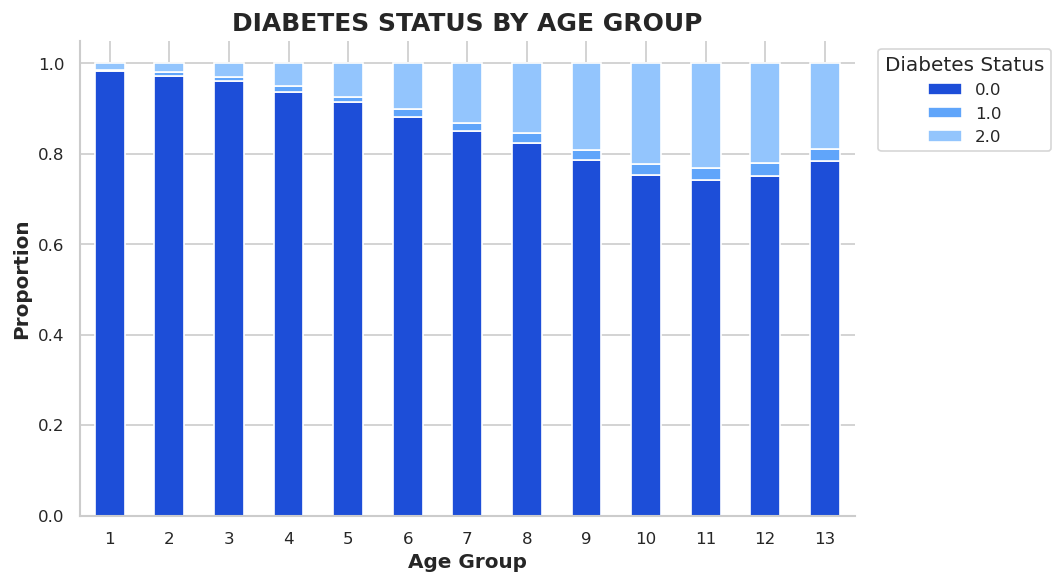

In [70]:
age_ratio = pd.crosstab(
    df["Age"],
    df["Diabetes_012"],
    normalize="index"
)

age_ratio.plot(
    kind="bar",
    stacked=True,
    figsize=(9,5),
    color=["#1D4ED8", "#60A5FA", "#93C5FD"]
)

plt.title("DIABETES STATUS BY AGE GROUP")
plt.xlabel("Age Group")
plt.xticks(
    ticks=range(13),
    labels=range(1,14),
    rotation=0
)
plt.ylabel("Proportion")

plt.legend(
    title="Diabetes Status",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True
)

plt.tight_layout()
plt.show()

**Nhận xét**

- Ở các nhóm tuổi thấp (1–5), **No Diabetes** chiếm gần như toàn bộ số quan sát.
- Khi nhóm tuổi tăng, tỷ lệ **No Diabetes** có xu hướng giảm, trong khi tỷ lệ **Prediabetes** và **Diabetes** tăng dần.
- Nhóm tuổi từ **9 đến 12** có tỷ lệ mắc bệnh và tiền tiểu đường cao nhất.
- Kết quả cho thấy **Age** có mối liên hệ rõ ràng với nguy cơ mắc bệnh tiểu đường và là một đặc trưng quan trọng trong quá trình xây dựng mô hình dự đoán.

### **3.5 Correlation Analysis**

Để hiểu mối quan hệ tuyến tính giữa các đặc trưng trong bộ dữ liệu, ma trận tương quan được sử dụng. Kết quả giúp xác định các đặc trưng có liên hệ với biến mục tiêu và kiểm tra hiện tượng đa cộng tuyến.

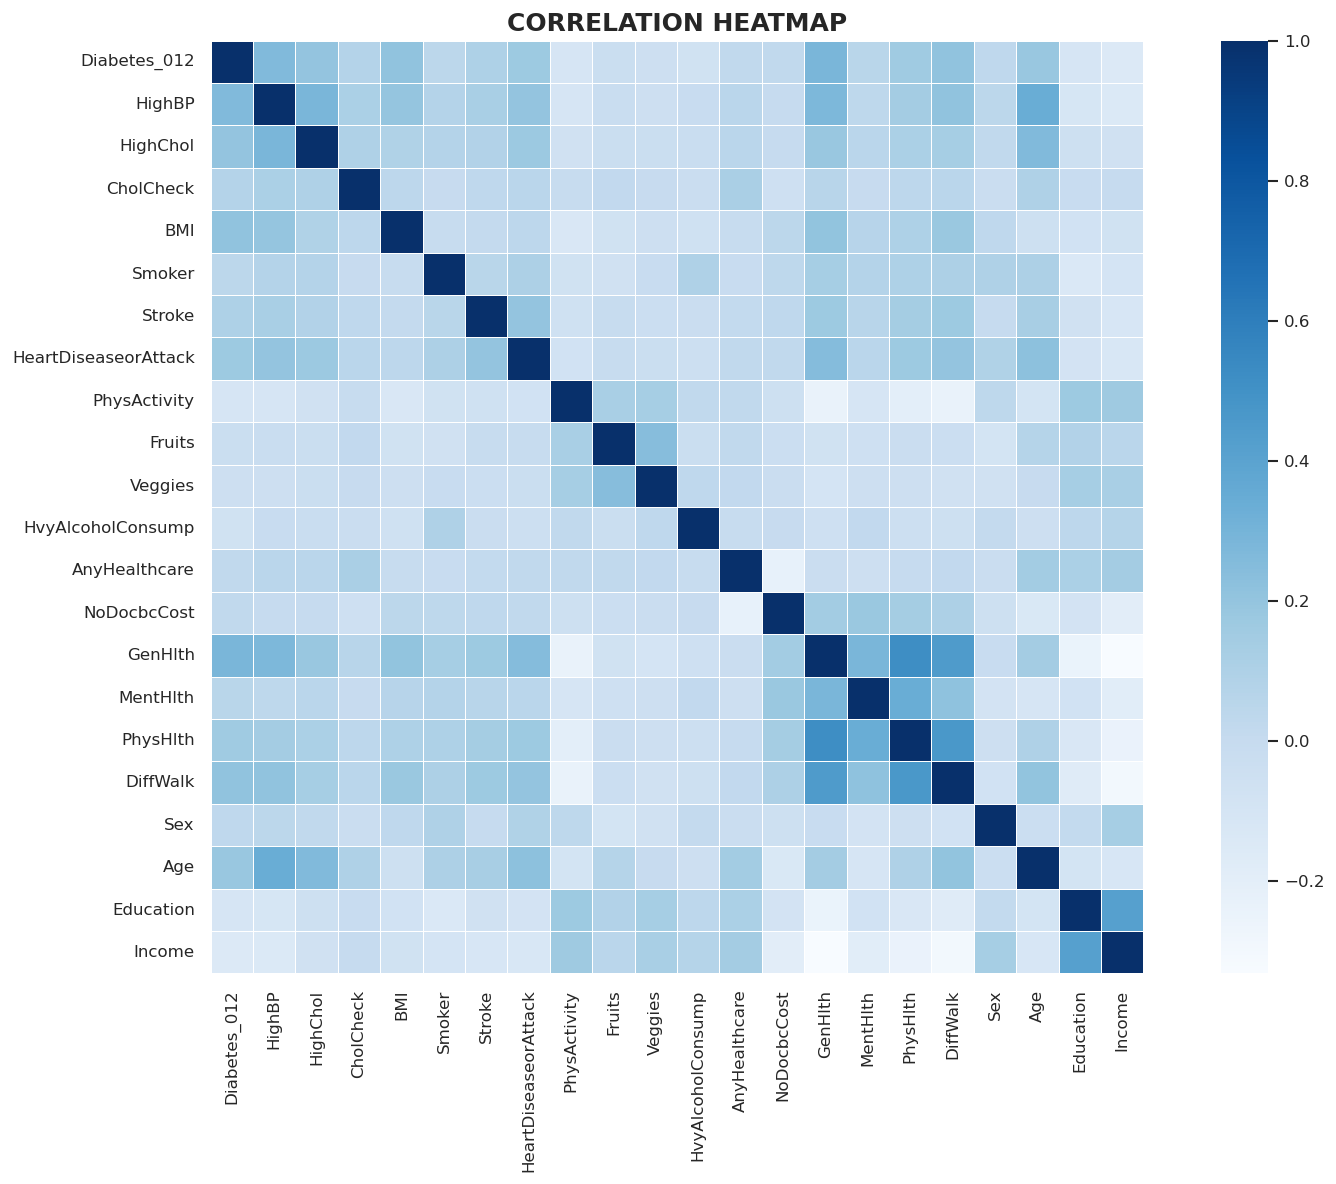

In [71]:
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="Blues",
    annot=False,
    square=True,
    linewidths=0.5
)

plt.title("CORRELATION HEATMAP")

plt.tight_layout()
plt.show()

**Nhận xét**

- Phần lớn các đặc trưng chỉ có mức tương quan thấp đến trung bình, cho thấy hiện tượng đa cộng tuyến không đáng kể.
- Một số đặc trưng như **GenHlth**, **BMI**, **HighBP**, **Age** và **DiffWalk** có mức tương quan cao hơn với biến mục tiêu **Diabetes_012**.
- Các đặc trưng sức khỏe có xu hướng tương quan với nhau, tuy nhiên không xuất hiện cặp biến nào có hệ số tương quan quá cao (|r| > 0.8).
- Kết quả này cho thấy các biến đều có khả năng đóng góp thông tin cho mô hình và sẽ được đánh giá thêm bằng phương pháp Mutual Information ở bước tiếp theo.

## **4. Feature Engineering & Selection**

### **4.1 Create Binary Target**

Biến mục tiêu ban đầu (**Diabetes_012**) gồm ba lớp:

- 0: No Diabetes
- 1: Prediabetes
- 2: Diabetes

Trong dự án này, bài toán được chuyển thành **phân loại nhị phân** nhằm phát hiện người có nguy cơ mắc bệnh.

Do đó:

- 0 → No Diabetes
- 1 và 2 → Diabetes Risk

Việc chuyển đổi được thực hiện vì các lý do sau:

- **Phù hợp với mục tiêu của dự án:** Mục tiêu là phát hiện những người có nguy cơ mắc bệnh tiểu đường để hỗ trợ sàng lọc sớm. Do đó, cả nhóm **Prediabetes** và **Diabetes** đều được xem là nhóm có nguy cơ.

- **Giảm mất cân bằng dữ liệu:** Trong bộ dữ liệu gốc, lớp **Prediabetes** có số lượng mẫu rất ít so với hai lớp còn lại. Điều này khiến mô hình đa lớp khó học và thường cho kết quả dự đoán kém đối với lớp này. Sau khi gộp, tỷ lệ giữa hai lớp trở nên cân bằng hơn, giúp mô hình học hiệu quả hơn.

- **Đơn giản hóa bài toán:** Thay vì phân biệt ba trạng thái sức khỏe, mô hình chỉ cần xác định người tham gia có thuộc nhóm nguy cơ mắc bệnh hay không. Điều này giúp việc huấn luyện và đánh giá mô hình trở nên đơn giản hơn.

In [72]:
# số lượng mẫu trước và sau khi gộp
print(f"Số lượng mẫu trước khi gộp: {df['Diabetes_012'].value_counts()}" )

df["Diabetes_binary"] = df["Diabetes_012"].replace({
    0: 0,
    1: 1,
    2: 1
})

# Remove original target
df = df.drop(columns=["Diabetes_012"])

print(f"Số lượng mẫu sau khi gộp: {df['Diabetes_binary'].value_counts()}" )

Số lượng mẫu trước khi gộp: Diabetes_012
0.0    190055
2.0     35097
1.0      4629
Name: count, dtype: int64
Số lượng mẫu sau khi gộp: Diabetes_binary
0.0    190055
1.0     39726
Name: count, dtype: int64


**Nhận xét**

Lớp Prediabetes có số lượng mẫu rất nhỏ, dẫn đến hiện tượng mất cân bằng giữa các lớp trong bài toán phân loại đa lớp. Việc gộp Prediabetes và Diabetes giúp giảm mức độ mất cân bằng và tăng khả năng học của mô hình.

### **4.2 Feature Selection using Mutual Information**

Sau khi xây dựng biến mục tiêu nhị phân, tiến hành đánh giá mức độ đóng góp của từng đặc trưng bằng phương pháp **Mutual Information (MI)**.

Mutual Information đo lường lượng thông tin mà mỗi đặc trưng cung cấp cho biến mục tiêu. Giá trị MI càng lớn cho thấy đặc trưng càng hữu ích trong việc dự đoán nguy cơ mắc bệnh tiểu đường.

Kết quả MI sẽ được sử dụng làm cơ sở để lựa chọn các đặc trưng trước khi xây dựng mô hình.

In [73]:
from sklearn.feature_selection import mutual_info_classif

X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"]

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_scores = pd.Series(
    mi_scores,
    index=X.columns
).sort_values(ascending=False)

mi_scores

HighBP                  0.053335
GenHlth                 0.048509
AnyHealthcare           0.046209
CholCheck               0.044222
PhysActivity            0.043200
HighChol                0.037819
Veggies                 0.035877
Fruits                  0.032244
BMI                     0.030151
Age                     0.025977
Smoker                  0.023811
DiffWalk                0.021157
Sex                     0.020212
Education               0.019379
Income                  0.018179
PhysHlth                0.012498
HeartDiseaseorAttack    0.011395
MentHlth                0.003661
Stroke                  0.002871
HvyAlcoholConsump       0.002371
NoDocbcCost             0.000044
dtype: float64

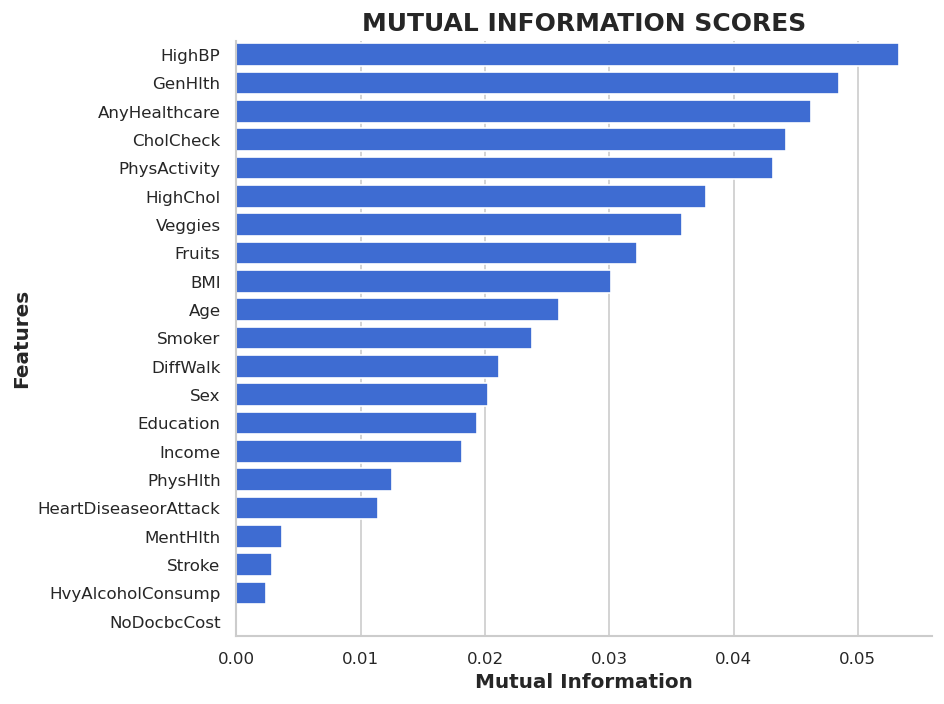

In [74]:
plt.figure(figsize=(8,6))

sns.barplot(
    x=mi_scores.values,
    y=mi_scores.index,
    color="#2563EB"
)

plt.title("MUTUAL INFORMATION SCORES")
plt.xlabel("Mutual Information")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

**Nhận xét**

- Kết quả Mutual Information cho thấy **HighBP**, **GenHlth**, **AnyHealthcare**, **CholCheck** và **PhysActivity** là những đặc trưng cung cấp nhiều thông tin nhất cho việc dự đoán nguy cơ mắc bệnh tiểu đường.
- Các đặc trưng như **BMI**, **Age**, **Smoker** và **DiffWalk** cũng có mức độ đóng góp đáng kể và sẽ được giữ lại trong mô hình.
- Ngược lại, **NoDocbcCost**, **HvyAlcoholConsump**, **Stroke** và **MentHlth** có điểm Mutual Information rất thấp, cho thấy lượng thông tin mà các biến này cung cấp cho biến mục tiêu còn hạn chế.
- Dựa trên kết quả này kết hợp với mục tiêu của bài toán, các đặc trưng có điểm MI thấp sẽ được xem xét loại bỏ nhằm giảm độ phức tạp của mô hình.

### **4.3 Remove Low-information Features**

Dựa trên kết quả Mutual Information, kết hợp với mục tiêu của bài toán và ý nghĩa của từng đặc trưng, các biến có mức đóng góp rất thấp được loại bỏ nhằm đơn giản hóa mô hình và giảm nhiễu trong dữ liệu.

In [75]:
low_features = [
    "Stroke",
    "MentHlth",
    "NoDocbcCost",
    "HvyAlcoholConsump"
]

df = df.drop(columns=low_features)

print("Phân tích các đặc trưng:")
print(df.shape)

Phân tích các đặc trưng:
(229781, 18)


In [76]:
df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,AnyHealthcare,GenHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,1.0,1.0,5.0,15.0,1.0,0.0,9.0,4.0,3.0,0.0
1,0.0,0.0,0.0,25.0,1.0,0.0,1.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,7.0,6.0,1.0,0.0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,1.0,0.0,1.0,5.0,30.0,1.0,0.0,9.0,4.0,8.0,0.0
3,1.0,0.0,1.0,27.0,0.0,0.0,1.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,11.0,3.0,6.0,0.0
4,1.0,1.0,1.0,24.0,0.0,0.0,1.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,11.0,5.0,4.0,0.0


 **Nhận xét**

Sau khi đánh giá bằng Mutual Information, bốn đặc trưng gồm **NoDocbcCost**, **HvyAlcoholConsump**, **Stroke** và **MentHlth** được loại bỏ do có mức đóng góp rất thấp đối với biến mục tiêu. Các đặc trưng còn lại được giữ lại để phục vụ quá trình xây dựng mô hình.

## **5. Data Preprocessing**

### **5.1 Outlier Detection & Treatment**

Qua biểu đồ phân bố BMI và boxplot ở phần EDA, có thể thấy chỉ số BMI xuất hiện một số giá trị rất lớn.

Để hạn chế ảnh hưởng của các giá trị ngoại lệ nhưng vẫn giữ lại thông tin của dữ liệu, phương pháp **IQR (Interquartile Range)** được sử dụng để xác định và xử lý outliers.

In [77]:
# Outlier detection for BMI
Q1 = df["BMI"].quantile(0.25)
Q3 = df["BMI"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Lower bound: {lower:.2f}")
print(f"Upper bound: {upper:.2f}")

Lower bound: 12.00
Upper bound: 44.00


In [78]:
outliers = df[(df["BMI"] < lower) | (df["BMI"] > upper)]

print(f"Number of outliers: {len(outliers)}")
print(f"Percentage: {len(outliers)/len(df)*100:.2f}%")

Number of outliers: 5638
Percentage: 2.45%


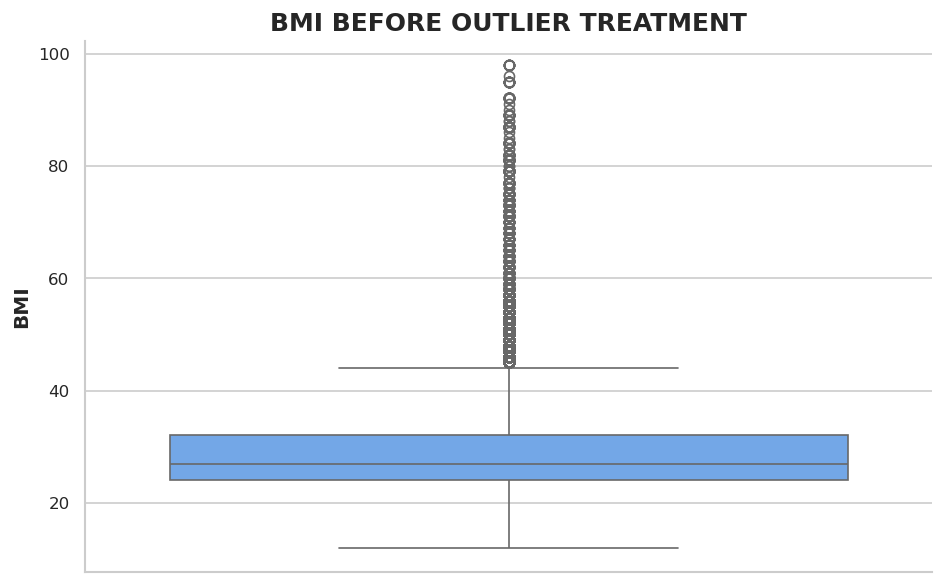

In [79]:
plt.figure()

sns.boxplot(
    y=df["BMI"],
    color="#60A5FA"
)

plt.title("BMI BEFORE OUTLIER TREATMENT")
plt.ylabel("BMI")

plt.tight_layout()
plt.show()

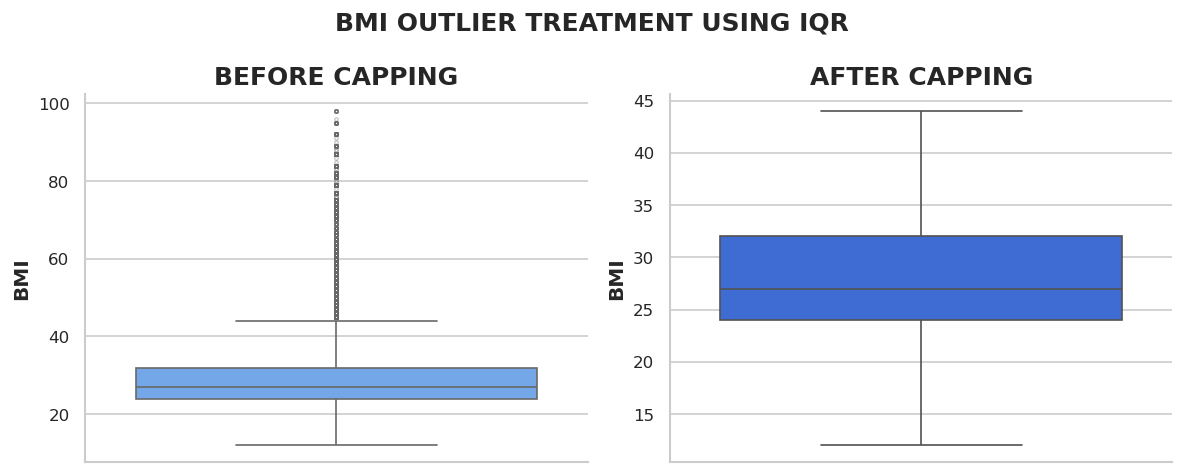

In [80]:
df_before = df.copy()
df["BMI"] = df["BMI"].clip(lower=lower, upper=upper)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before
sns.boxplot(
    y=df_before["BMI"],
    color="#60A5FA",
    showfliers=True,
    flierprops=dict(
        marker='o',
        markersize=2,
        alpha=0.3
    ),
    ax=axes[0]
)

axes[0].set_title("BEFORE TREATMENT")
axes[0].set_ylabel("BMI")

# After
sns.boxplot(
    y=df["BMI"],
    color="#2563EB",
    showfliers=True,
    ax=axes[1]
)

axes[0].set_title("BEFORE CAPPING")
axes[1].set_title("AFTER CAPPING")

plt.suptitle(
    "BMI OUTLIER TREATMENT USING IQR",
    fontsize=15,
    fontweight="bold"
)


plt.tight_layout()
plt.show()

**Nhận xét**

Kết quả cho thấy biến BMI xuất hiện một số giá trị ngoại lệ theo phương pháp IQR. Thay vì loại bỏ các quan sát này, phương pháp capping được áp dụng để giới hạn các giá trị vượt ngưỡng về khoảng cho phép. Cách tiếp cận này giúp giảm ảnh hưởng của ngoại lệ trong khi vẫn giữ nguyên số lượng mẫu của bộ dữ liệu.

### **5.2 Train / Validation / Test Split**

Bộ dữ liệu được chia thành ba tập:

- **Training set (70%)**: dùng để huấn luyện mô hình.
- **Validation set (15%)**: dùng để điều chỉnh siêu tham số và lựa chọn mô hình.
- **Test set (15%)**: dùng để đánh giá hiệu quả cuối cùng của mô hình trên dữ liệu chưa từng được sử dụng trong quá trình huấn luyện.

Việc chia dữ liệu theo tỷ lệ 70:15:15 giúp đảm bảo quá trình đánh giá khách quan và hạn chế hiện tượng overfitting.

In [81]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"]

# Train (70%) - Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# Validation (15%) - Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Training set :", X_train.shape)
print("Validation set:", X_val.shape)
print("Testing set  :", X_test.shape)

Training set : (160846, 17)
Validation set: (34467, 17)
Testing set  : (34468, 17)


**Nhận xét**

Dữ liệu đã được chia thành ba tập theo tỷ lệ **70:15:15**. Đồng thời, tham số `stratify` được sử dụng để giữ nguyên tỷ lệ giữa hai lớp trong cả ba tập dữ liệu, giúp hạn chế sai lệch về phân bố lớp trong quá trình huấn luyện và đánh giá.

### **5.3 Feature Scaling**

Các đặc trưng được chuẩn hóa bằng **StandardScaler** nhằm đưa dữ liệu về cùng một thang đo.

Bộ chuẩn hóa được huấn luyện (fit) trên tập huấn luyện, sau đó áp dụng (transform) cho tập validation và tập test để tránh rò rỉ dữ liệu (data leakage).

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train_scaled.shape)
print("Validation set:", X_val_scaled.shape)
print("Testing set:", X_test_scaled.shape)

Training set: (160846, 17)
Validation set: (34467, 17)
Testing set: (34468, 17)


**Nhận xét**

Sau khi chuẩn hóa, các đặc trưng được đưa về cùng một thang đo với trung bình xấp xỉ 0 và độ lệch chuẩn xấp xỉ 1. Điều này giúp các thuật toán dựa trên khoảng cách hoặc tối ưu hóa như Logistic Regression hoạt động hiệu quả hơn.

### **5.4 Handle Class Imbalance (SMOTE)**

Do bộ dữ liệu vẫn tồn tại sự mất cân bằng giữa hai lớp, kỹ thuật **SMOTE (Synthetic Minority Over-sampling Technique)** được áp dụng trên **tập huấn luyện đã được chuẩn hóa** nhằm tăng số lượng mẫu của lớp thiểu số.

Việc chỉ áp dụng SMOTE trên tập huấn luyện giúp tránh hiện tượng data leakage và cải thiện khả năng dự đoán của mô hình đối với lớp thiểu số.

In [83]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
Diabetes_binary
0.0    133038
1.0     27808
Name: count, dtype: int64

After SMOTE
Diabetes_binary
0.0    133038
1.0    133038
Name: count, dtype: int64


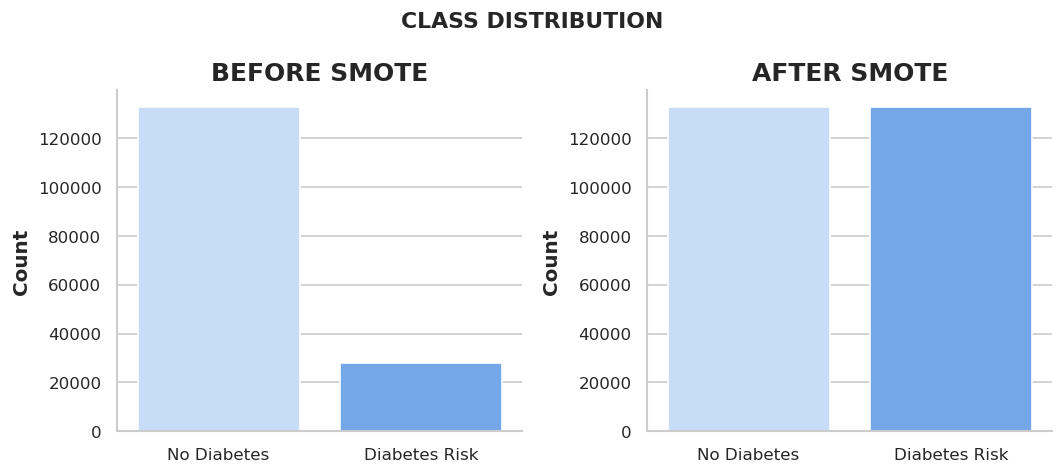

In [89]:
before = y_train.value_counts().sort_index()
after = y_train_smote.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Before SMOTE
sns.barplot(
    x=["No Diabetes", "Diabetes Risk"],
    y=before.values,
    palette=PALETTE[:2],
    ax=axes[0]
)

axes[0].set_title("BEFORE SMOTE")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")

# After SMOTE
sns.barplot(
    x=["No Diabetes", "Diabetes Risk"],
    y=after.values,
    palette=PALETTE[:2],
    ax=axes[1]
)

axes[1].set_title("AFTER SMOTE")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")

plt.suptitle("CLASS DISTRIBUTION", fontweight="bold")

plt.tight_layout()
plt.show()

**Nhận xét**

Trước khi áp dụng SMOTE, số lượng mẫu của lớp **Diabetes Risk** thấp hơn đáng kể so với lớp **No Diabetes**, thể hiện tình trạng mất cân bằng dữ liệu.

Sau khi áp dụng SMOTE, số lượng mẫu của hai lớp trở nên cân bằng. Điều này giúp mô hình học tốt hơn đối với lớp thiểu số và giảm xu hướng dự đoán thiên lệch về lớp chiếm ưu thế.

## **6. Model Building**

### **6.1 Logistic Regression**

Logistic Regression được lựa chọn làm mô hình cơ sở (baseline) để đánh giá hiệu quả của các mô hình nâng cao. Đây là thuật toán phân loại tuyến tính, có khả năng diễn giải tốt và thường được sử dụng trong các bài toán phân loại nhị phân.

**Train model**

In [91]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

**Prediction**

In [92]:
y_pred_log = log_model.predict(X_val_scaled)
y_prob_log = log_model.predict_proba(X_val_scaled)[:, 1]

**Evaluation**

In [93]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

log_metrics = {
    "Accuracy": accuracy_score(y_val, y_pred_log),
    "Precision": precision_score(y_val, y_pred_log),
    "Recall": recall_score(y_val, y_pred_log),
    "F1-score": f1_score(y_val, y_pred_log),
    "ROC-AUC": roc_auc_score(y_val, y_prob_log)
}

pd.DataFrame(log_metrics, index=["Logistic Regression"])

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.719123,0.353902,0.756503,0.482216,0.804545


**Classification Report**

In [94]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred_log))

              precision    recall  f1-score   support

         0.0       0.93      0.71      0.81     28508
         1.0       0.35      0.76      0.48      5959

    accuracy                           0.72     34467
   macro avg       0.64      0.73      0.64     34467
weighted avg       0.83      0.72      0.75     34467



**Confusion Matrix**

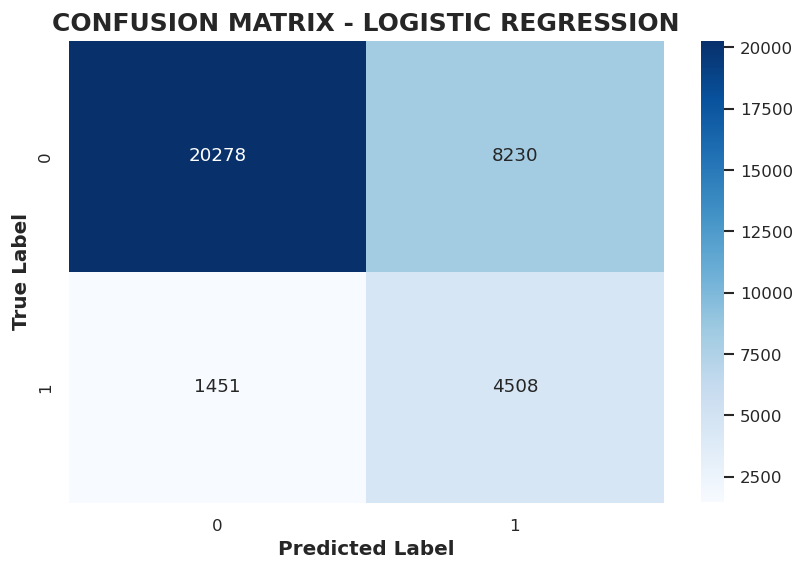

In [95]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred_log)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("CONFUSION MATRIX - LOGISTIC REGRESSION")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()